In [11]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Load Dataset
df = pd.read_csv(r"C:\Users\vishnupriya\OneDrive\Documents\GeoTaste-AI\data\Dataset.csv")

# Display First 5 Rows
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [12]:
# Dataset Shape
print("Dataset Shape:", df.shape)

# Missing Values
print("\nMissing Values:\n")
print(df.isnull().sum())

# Select Important Columns for Geo Analysis
geo_df = df[[
    'Restaurant Name',
    'City',
    'Locality',
    'Longitude',
    'Latitude',
    'Cuisines',
    'Aggregate rating',
    'Average Cost for two',
    'Price range',
    'Votes'
]]

# Remove Missing Values
geo_df.dropna(inplace=True)

# Remove Duplicate Restaurants
geo_df.drop_duplicates(inplace=True)

# Final Dataset Shape
print("\nCleaned Dataset Shape:", geo_df.shape)

# Preview Cleaned Data
geo_df.head()

Dataset Shape: (9551, 21)

Missing Values:

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

Cleaned Dataset Shape: (9542, 10)


,Restaurant Name,City,Locality,Longitude,Latitude,Cuisines,Aggregate rating,Average Cost for two,Price range,Votes
0,Le Petit Souffle,Makati City,"Century City Mall, Poblacion, Makati City",121.027535,14.565443,"French, Japanese, Desserts",4.8,1100,3,314
1,Izakaya Kikufuji,Makati City,"Little Tokyo, Legaspi Village, Makati City",121.014101,14.553708,Japanese,4.5,1200,3,591
2,Heat - Edsa Shangri-La,Mandaluyong City,"Edsa Shangri-La, Ortigas, Mandaluyong City",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",4.4,4000,4,270
3,Ooma,Mandaluyong City,"SM Megamall, Ortigas, Mandaluyong City",121.056475,14.585318,"Japanese, Sushi",4.9,1500,4,365
4,Sambo Kojin,Mandaluyong City,"SM Megamall, Ortigas, Mandaluyong City",121.057508,14.584450,"Japanese, Korean",4.8,1500,4,229


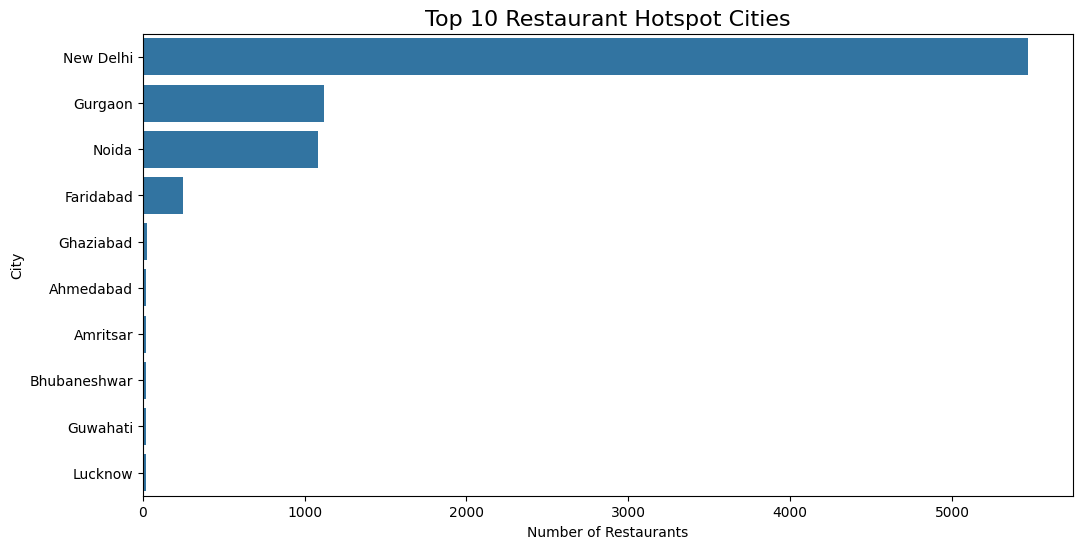

In [13]:
# Top 10 Cities with Most Restaurants

top_cities = geo_df['City'].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_cities.values,
    y=top_cities.index
)

plt.title("Top 10 Restaurant Hotspot Cities", fontsize=16)
plt.xlabel("Number of Restaurants")
plt.ylabel("City")

plt.show()

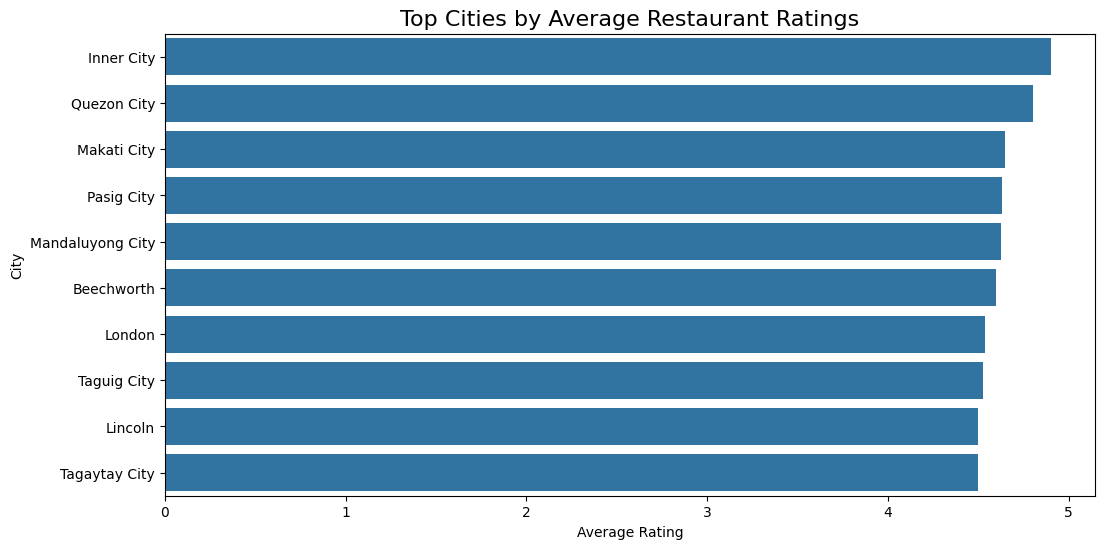

In [14]:
# Average Restaurant Ratings by City

city_ratings = geo_df.groupby('City')['Aggregate rating'].mean()

# Top 10 Highest Rated Cities
top_rated_cities = city_ratings.sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_rated_cities.values,
    y=top_rated_cities.index
)

plt.title("Top Cities by Average Restaurant Ratings", fontsize=16)
plt.xlabel("Average Rating")
plt.ylabel("City")

plt.show()

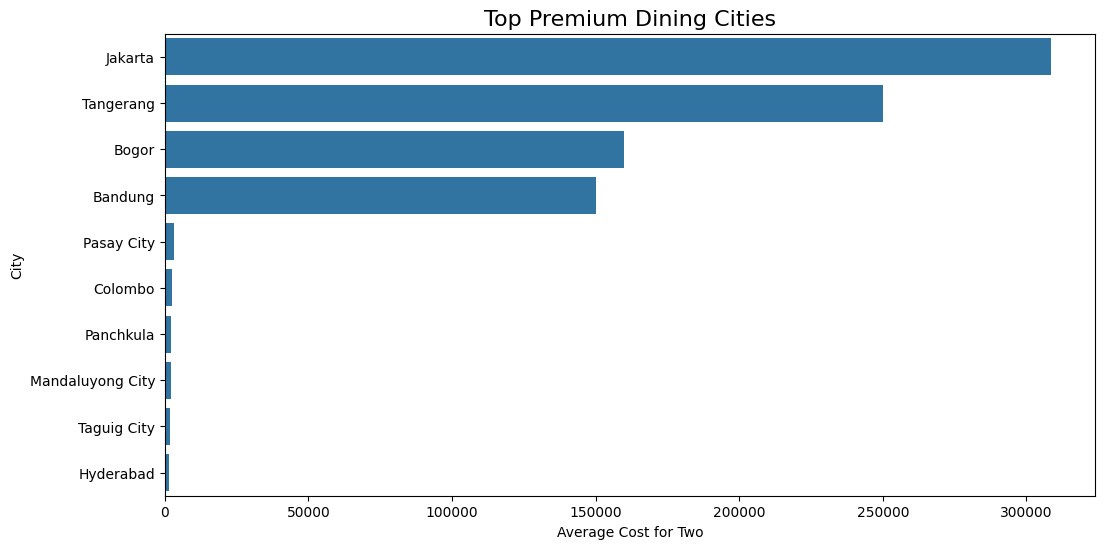

In [15]:
# Average Cost Analysis by City

city_cost = geo_df.groupby('City')['Average Cost for two'].mean()

# Top 10 Most Expensive Cities
expensive_cities = city_cost.sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=expensive_cities.values,
    y=expensive_cities.index
)

plt.title("Top Premium Dining Cities", fontsize=16)
plt.xlabel("Average Cost for Two")
plt.ylabel("City")

plt.show()

In [16]:
# Normalize Votes
geo_df['Normalized Votes'] = (
    geo_df['Votes'] - geo_df['Votes'].min()
) / (
    geo_df['Votes'].max() - geo_df['Votes'].min()
)

# Create AI Geo Intelligence Score
geo_df['Geo Intelligence Score'] = (
    0.5 * geo_df['Aggregate rating'] +
    0.3 * geo_df['Normalized Votes'] +
    0.2 * geo_df['Price range']
)

# Top Smart Restaurant Locations
top_geo = geo_df.sort_values(
    by='Geo Intelligence Score',
    ascending=False
).head(10)

# Display Results
top_geo[[
    'Restaurant Name',
    'City',
    'Aggregate rating',
    'Votes',
    'Price range',
    'Geo Intelligence Score'
]]

,Restaurant Name,City,Aggregate rating,Votes,Price range,Geo Intelligence Score
728,Toit,Bangalore,4.8,10934,4,3.500000
3601,Indian Accent - The Manor,New Delhi,4.9,1934,4,3.303064
597,Tresind - Nassima Royal Hotel,Dubai,4.9,1352,4,3.287095
428,Mama's Fish House,Rest of Hawaii,4.9,1343,4,3.286848
2289,Barbeque Nation,Guwahati,4.9,774,4,3.271237
8,Spiral - Sofitel Philippine Plaza Manila,Pasay City,4.9,621,4,3.267039
9540,Draft Gastro Pub,��stanbul,4.9,522,4,3.264322
9457,Cube - Tasting Kitchen,Inner City,4.9,441,4,3.262100
4298,Masala Library,New Delhi,4.9,408,4,3.261194
3,Ooma,Mandaluyong City,4.9,365,4,3.260015


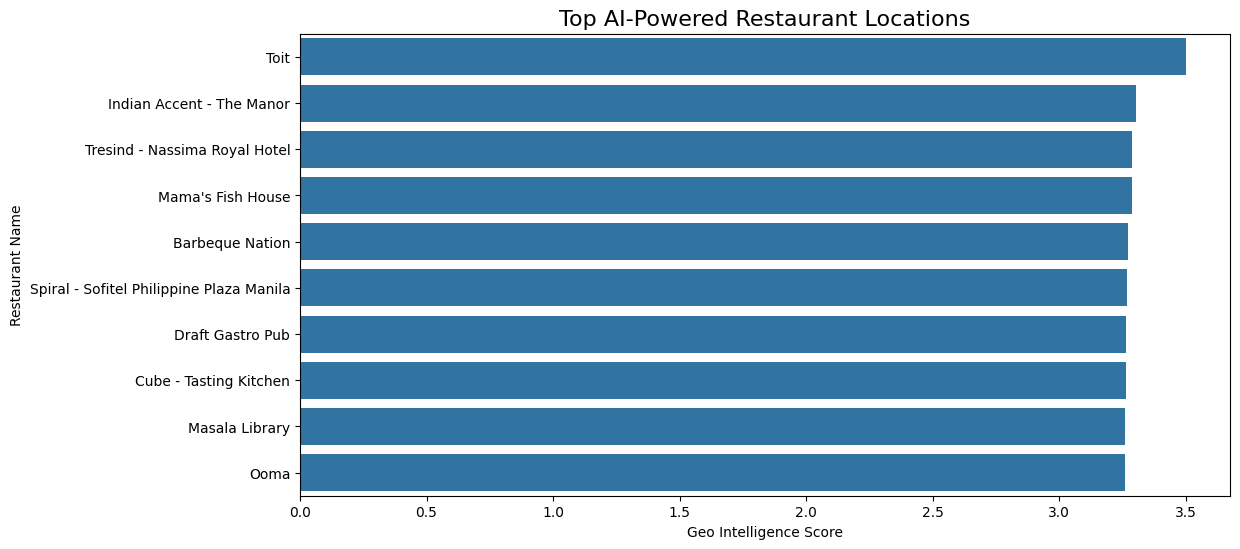

In [17]:
# Top 10 AI-Powered Restaurant Locations

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_geo['Geo Intelligence Score'],
    y=top_geo['Restaurant Name']
)

plt.title("Top AI-Powered Restaurant Locations", fontsize=16)
plt.xlabel("Geo Intelligence Score")
plt.ylabel("Restaurant Name")

plt.show()

In [18]:
!pip install folium

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\vishnupriya\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [19]:
import folium

# Create Base Map
restaurant_map = folium.Map(
    location=[
        geo_df['Latitude'].mean(),
        geo_df['Longitude'].mean()
    ],
    zoom_start=2
)

# Add Restaurant Markers
for index, row in geo_df.head(200).iterrows():

    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=5,
        popup=row['Restaurant Name'],
        color='blue',
        fill=True,
        fill_color='blue'
    ).add_to(restaurant_map)

# Display Interactive Map
restaurant_map

In [20]:
# Save Interactive Map
restaurant_map.save("restaurant_geo_map.html")

print("Interactive map saved successfully!")

Interactive map saved successfully!
